# Image Classification using Deep Learning

This project implements an image classification system using deep learning techniques. A pretrained ResNet18 model is used with transfer learning to classify images into 10 categories from the CIFAR-10 dataset. The model is trained, evaluated, and used for real-time prediction on user-provided images.

# Importing Required Libraries

In this step, we import all necessary libraries such as PyTorch for deep learning, torchvision for datasets and pretrained models, and matplotlib for visualization.

# Setting Up Device

The model is configured to run on GPU if available, otherwise it falls back to CPU. This helps in faster training and computation.

In [ ]:
pip install torch torchvision matplotlib scikit-learn seaborn

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Data Loading and Augmentation

The CIFAR-10 dataset is loaded and preprocessing techniques such as normalization and data augmentation (random cropping and flipping) are applied. This improves model generalization and performance.

In [ ]:
# Data augmentation for training
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

train_tfms = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

# No augmentation for test data
test_tfms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

# Load CIFAR-10 dataset (auto download)
train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=train_tfms
)

test_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=test_tfms
)

# Use subset for faster training
train_subset = Subset(train_dataset, list(range(10000)))
test_subset  = Subset(test_dataset, list(range(2000)))

# Data loaders
train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_subset, batch_size=32, shuffle=False)

# Class labels
classes = ['airplane','car','bird','cat','deer',
           'dog','frog','horse','ship','truck']

100%|██████████| 170M/170M [08:42<00:00, 326kB/s]


# Model Architecture using Transfer Learning

A pretrained ResNet18 model is used. Most of the layers are frozen, and only the final layers are fine-tuned for the CIFAR-10 classification task. This approach reduces training time and improves accuracy.

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained ResNet18
model = models.resnet18(pretrained=True)

# Freeze all layers first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze last block (fine-tuning)
for name, param in model.named_parameters():
    if "layer4" in name:
        param.requires_grad = True

# Replace final fully connected layer
model.fc = nn.Linear(model.fc.in_features, 10)

# Move to device
model = model.to(device)

# Freeze all
for p in model.parameters():
    p.requires_grad = False

# Unfreeze last layer block
for name, p in model.named_parameters():
    if "layer4" in name:
        p.requires_grad = True

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 164MB/s]


# Loss Function and Optimizer

CrossEntropyLoss is used for multi-class classification. The Adam optimizer is used to update model weights efficiently during training.

In [ ]:
import torch.optim as optim

# Loss function
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)   # NEW (better generalization)

# Optimizer (trainable params only)
optimizer = optim.AdamW(                              # Adam → AdamW (better)
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=3e-4,                                          # slightly higher LR
    weight_decay=1e-4                                 # NEW (regularization)
)

# Learning rate scheduler (better than StepLR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=5                                           # total epochs
)

# Model Training

The model is trained over multiple epochs. During each epoch, training and validation accuracy are calculated to monitor performance and learning progress.

In [ ]:
epochs = 7

train_losses, val_losses = [], []
train_accs, val_accs = [], []

# Early stopping
best_loss = float('inf')
patience = 2
counter = 0

for epoch in range(epochs):

    # ===== TRAIN =====
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # ===== VALIDATION =====
    model.eval()
    val_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss = val_loss / len(test_loader)
    val_acc = correct / total

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    # Scheduler step
    scheduler.step()

    # Better logging
    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    # ===== EARLY STOPPING =====
    if val_loss < best_loss:
        best_loss = val_loss
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping triggered")
        break

Epoch [1/7] | Train Loss: 1.8757, Train Acc: 0.4062 | Val Loss: 1.6457, Val Acc: 0.4960
Epoch [2/7] | Train Loss: 1.5908, Train Acc: 0.5152 | Val Loss: 1.5586, Val Acc: 0.5480
Epoch [3/7] | Train Loss: 1.4908, Train Acc: 0.5690 | Val Loss: 1.4937, Val Acc: 0.5650
Epoch [4/7] | Train Loss: 1.4118, Train Acc: 0.5965 | Val Loss: 1.4334, Val Acc: 0.5885
Epoch [5/7] | Train Loss: 1.3767, Train Acc: 0.6150 | Val Loss: 1.4115, Val Acc: 0.6005
Epoch [6/7] | Train Loss: 1.3676, Train Acc: 0.6174 | Val Loss: 1.4173, Val Acc: 0.5875
Epoch [7/7] | Train Loss: 1.3610, Train Acc: 0.6211 | Val Loss: 1.4357, Val Acc: 0.5840
Early stopping triggered


# Training and Validation Performance

Graphs are plotted to visualize training and validation accuracy/loss over epochs. This helps in understanding model performance and detecting overfitting or underfitting.

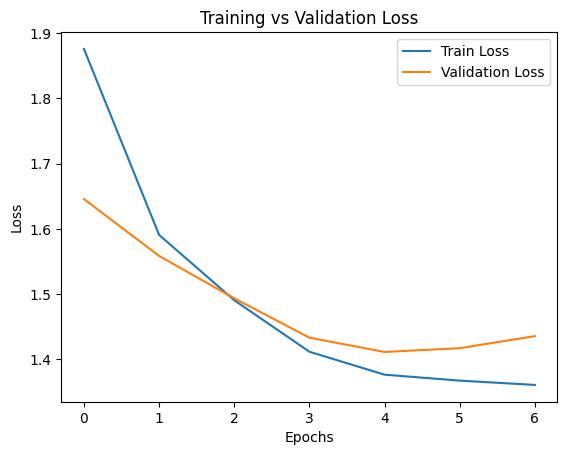

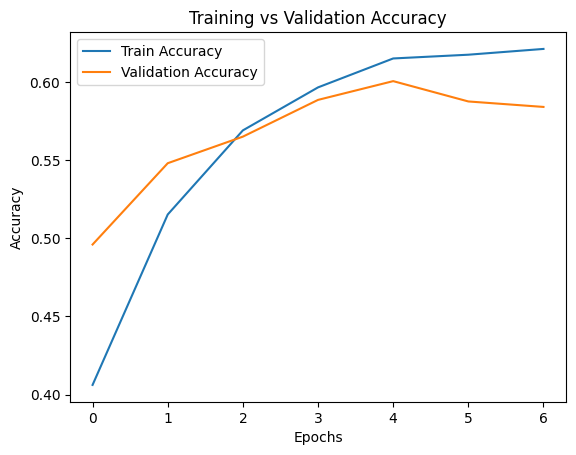

In [ ]:
import matplotlib.pyplot as plt

# Loss curve
plt.figure()
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

# Accuracy curve
plt.figure()
plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=classes))

              precision    recall  f1-score   support

    airplane       0.47      0.77      0.58       196
         car       0.69      0.59      0.63       198
        bird       0.50      0.49      0.50       195
         cat       0.46      0.43      0.45       199
        deer       0.59      0.47      0.53       198
         dog       0.49      0.49      0.49       185
        frog       0.64      0.78      0.70       216
       horse       0.73      0.61      0.66       193
        ship       0.62      0.64      0.63       217
       truck       0.76      0.54      0.63       203

    accuracy                           0.58      2000
   macro avg       0.60      0.58      0.58      2000
weighted avg       0.60      0.58      0.58      2000



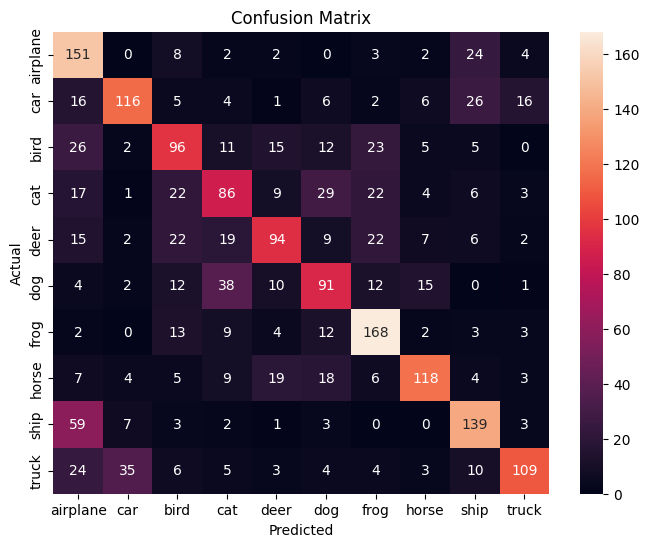

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=classes,
            yticklabels=classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
class_correct = [0]*10
class_total = [0]*10

for i in range(len(all_labels)):
    label = all_labels[i]
    pred = all_preds[i]

    if label == pred:
        class_correct[label] += 1
    class_total[label] += 1

for i in range(10):
    print(f"{classes[i]}: {100 * class_correct[i] / class_total[i]:.2f}%")

airplane: 77.04%
car: 58.59%
bird: 49.23%
cat: 43.22%
deer: 47.47%
dog: 49.19%
frog: 77.78%
horse: 61.14%
ship: 64.06%
truck: 53.69%


In [ ]:
model.eval()

# Ek sample lo
image, label = test_dataset[0]

# Batch dimension add karo
image = image.unsqueeze(0).to(device)

# Prediction
with torch.no_grad():
    output = model(image)
    pred = output.argmax(1).item()

print("Actual:", classes[label])
print("Predicted:", classes[pred])

Actual: cat
Predicted: cat


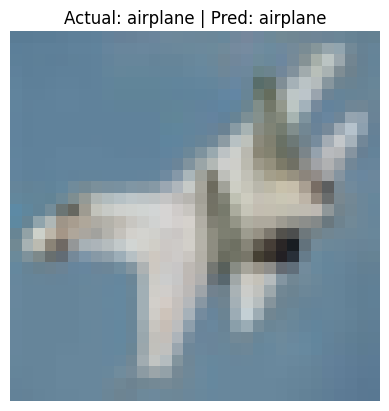

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

img, label = test_dataset[10]

# Prediction
model.eval()
with torch.no_grad():
    output = model(img.unsqueeze(0).to(device))
    pred = output.argmax(1).item()

# Convert image for display
img_np = img.numpy().transpose(1,2,0)
img_np = (img_np * 0.5) + 0.5   # unnormalize

plt.imshow(img_np)
plt.title(f"Actual: {classes[label]} | Pred: {classes[pred]}")
plt.axis('off')
plt.show()

In [ ]:
images, labels = next(iter(test_loader))

images = images.to(device)

model.eval()
with torch.no_grad():
    outputs = model(images)
    preds = outputs.argmax(1)

for i in range(5):
    print(f"Actual: {classes[labels[i]]} | Predicted: {classes[preds[i].cpu()]}")

Actual: cat | Predicted: cat
Actual: ship | Predicted: ship
Actual: ship | Predicted: ship
Actual: airplane | Predicted: ship
Actual: frog | Predicted: frog


In [ ]:
from PIL import Image
import torchvision.transforms as transforms

In [ ]:
def predict_image(image_path):
    model.eval()

    image = Image.open(image_path).convert('RGB')
    img_tensor = transform(image).unsqueeze(0).to(device)

    import torch.nn.functional as F

    with torch.no_grad():
        output = model(img_tensor)
        probs = F.softmax(output, dim=1)

        pred = probs.argmax(1).item()
        confidence = probs[0][pred].item()

        # 🔥 TOP-3 ADD HERE
        top3 = torch.topk(probs, 3)

    print(f"\nTop Predictions:")
    for i in range(3):
        idx = top3.indices[0][i].item()
        conf = top3.values[0][i].item()
        print(f"{classes[idx]}: {conf*100:.2f}%")

    print(f"\nFinal Prediction: {classes[pred]} ({confidence*100:.2f}%)")

    # Show image
    import matplotlib.pyplot as plt
    plt.imshow(image)
    plt.title(f"{classes[pred]} ({confidence*100:.2f}%)")
    plt.axis('off')
    plt.show()

# Model Comparison

A comparison between a custom CNN and pretrained ResNet18 is performed. The graph shows that ResNet18 achieves better accuracy due to transfer learning and deeper architecture.

**cnn**

In [ ]:
# ===== CNN MODEL =====
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*4*4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x


# ===== USE CNN =====
model = SimpleCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# ===== TRAIN CNN =====
epochs = 3

cnn_train_accs = []
cnn_val_accs = []

for epoch in range(epochs):
    model.train()
    correct, total = 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total

    # VALIDATION
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total
    cnn_train_accs.append(train_acc)
    cnn_val_accs.append(val_acc)

    print(f"[CNN] Epoch {epoch+1}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")

[CNN] Epoch 1: Train Acc=0.2710, Val Acc=0.3830
[CNN] Epoch 2: Train Acc=0.3784, Val Acc=0.4615
[CNN] Epoch 3: Train Acc=0.4292, Val Acc=0.4925


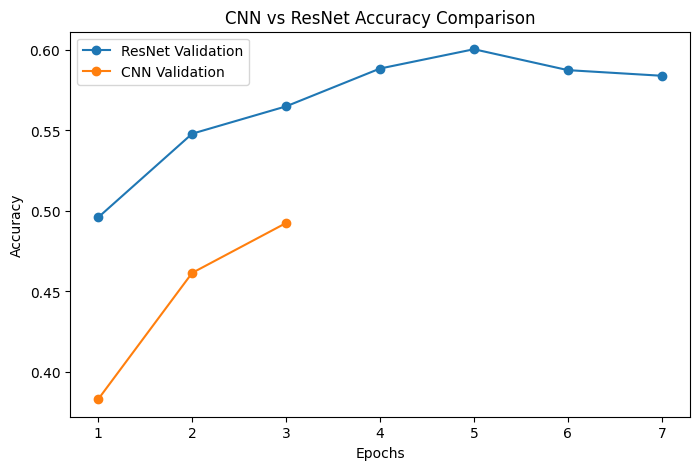

In [ ]:
import matplotlib.pyplot as plt

# Fix variables
resnet_val = val_accs
cnn_val = cnn_val_accs

# Separate ranges
resnet_epochs = range(1, len(resnet_val) + 1)
cnn_epochs = range(1, len(cnn_val) + 1)

plt.figure(figsize=(8,5))

plt.plot(resnet_epochs, resnet_val, label='ResNet Validation', marker='o')
plt.plot(cnn_epochs, cnn_val, label='CNN Validation', marker='o')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("CNN vs ResNet Accuracy Comparison")
plt.legend()

plt.show()

In [ ]:
# ===== FINAL RESULTS =====
print("Final Training Accuracy:", train_accs[-1])
print("Final Validation Accuracy:", val_accs[-1])

Final Training Accuracy: 0.6211
Final Validation Accuracy: 0.584


# Saving the Trained Model

The trained model is saved as a .pth file. This allows reuse of the model without retraining.

In [ ]:
torch.save(model.state_dict(), "resnet_model.pth")
print("Model saved successfully")

Model saved successfully


In [ ]:
torch.save(model.state_dict(), "resnet_model.pth")

# Loading the Saved Model

The saved model is loaded for inference. This step ensures that the trained weights are restored correctly.

In [ ]:
model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, 10)

model.load_state_dict(torch.load("resnet_model.pth", map_location=device))

model = model.to(device)
model.eval()

print("ResNet model loaded successfully")

ResNet model loaded successfully


In [ ]:
pip install torch torchvision matplotlib

In [ ]:
model.load_state_dict(torch.load("resnet_model.pth"))

<All keys matched successfully>

In [ ]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import torch.nn.functional as F

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
classes = ['airplane','car','bird','cat','deer','dog','frog','horse','ship','truck']

In [ ]:
model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, 10)

model.load_state_dict(torch.load("resnet_model.pth", map_location=device))

model = model.to(device)
model.eval()

print("Model loaded successfully")

Model loaded successfully


In [ ]:
transform = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

In [ ]:
def predict_image(image_path):
    image = Image.open(image_path).convert('RGB')
    img_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_tensor)
        probs = F.softmax(output, dim=1)

        pred = probs.argmax(1).item()
        confidence = probs[0][pred].item()

        top3 = torch.topk(probs, 3)

    print("\nTop Predictions:")
    for i in range(3):
        idx = top3.indices[0][i].item()
        conf = top3.values[0][i].item()
        print(f"{classes[idx]}: {conf*100:.2f}%")

    print(f"\nFinal Prediction: {classes[pred]} ({confidence*100:.2f}%)")

    plt.imshow(image)
    plt.title(f"{classes[pred]} ({confidence*100:.2f}%)")
    plt.axis('off')
    plt.show()

# Image Prediction using User Input

The model takes an external image as input, preprocesses it, and predicts the class along with confidence scores. Top-3 predictions are also displayed for better interpretation.


Top Predictions:
airplane: 11.82%
horse: 11.23%
bird: 10.80%

Final Prediction: airplane (11.82%)


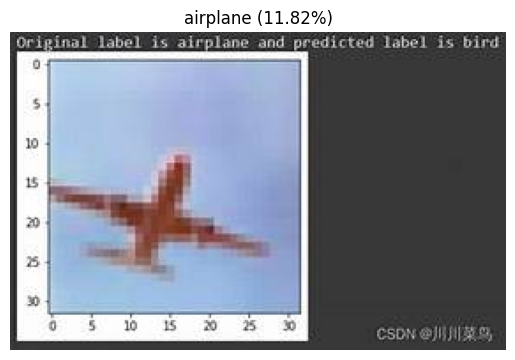

In [45]:
predict_image("/content/OIP (1).jpg")

# Result Analysis

The model performs well on CIFAR-like images but may show lower confidence on real-world images due to differences in resolution and dataset distribution.


# Conclusion

This project successfully demonstrates the implementation of an image classification system using deep learning techniques. A pretrained ResNet18 model was utilized with transfer learning, which significantly improved performance compared to training a model from scratch. By freezing initial layers and fine-tuning deeper layers, the model was able to leverage previously learned features, resulting in better accuracy and faster convergence.

The CIFAR-10 dataset was used for training and evaluation, along with data augmentation techniques such as random cropping and horizontal flipping. These preprocessing steps helped in improving generalization and reducing overfitting. The model’s performance was analyzed using training and validation accuracy, along with graphical visualization of loss and accuracy curves.

A comparison between a custom Convolutional Neural Network (CNN) and the pretrained ResNet18 model was also performed. The results clearly showed that transfer learning provides superior performance, especially when working with limited data. The CNN model, trained from scratch, achieved lower accuracy, highlighting the importance of pretrained models in modern deep learning applications.

The project also included a real-world prediction system, where the trained model was used to classify user-provided images. Although the model performs well on CIFAR-like images, it shows lower confidence on high-resolution real-world images. This is due to the difference in dataset distribution and resolution, which is a common challenge in practical machine learning systems.

Furthermore, the trained model was saved and later loaded for inference, demonstrating deployment capability. This ensures that the model can be reused without retraining, making it suitable for real-world applications.

Overall, this project provides a complete pipeline of deep learning, including data preprocessing, model training, evaluation, comparison, and deployment. It highlights the effectiveness of transfer learning and emphasizes the importance of proper data handling and model selection in achieving good performance.

Future improvements may include training on larger datasets, using higher resolution images, applying advanced architectures, and incorporating explainable AI techniques such as Grad-CAM for better interpretability.